In [1]:
"""
EMVP-Protected ResNet Inference
================================
Implements a small ResNet (ResNet-20 style) for image classification, where
the linear layers are evaluated using the EMVP query-only-privacy protocol.

Architecture
------------
  Input → Conv1 → BN1 → ReLU
        → [ResBlock x N_stages]
        → GlobalAveragePool          ← replaces max pooling
        → Linear (classifier)
        → Output logits

Protocol
--------
  • The server holds the model weights (public) and pre-computes M_hat = M @ D
    for each linear/conv layer during setup.
  • For each layer the client sends an encrypted query q_hat and receives back
    a compressed response M', which it decodes to get the layer output.
  • ReLU and average pooling are applied by the client on the decoded values.
  • One round-trip per layer; the server never sees the activations in the clear.

EMVP recap (query-only privacy)
---------------------------------
  Key:        sk = (C1 ∈ F^{k×ℓ},  alphas ∈ (F*)^s)
  Encoding:   M_hat = M @ D,  D = [-C1^T | I_ℓ] ∈ F^{ℓ×n},  n = k+ℓ
  Encrypt q:  q_tilde = c + [0_k | q],  c = a^T C  (random primal codeword)
              q_hat   = (α_1 q_tilde_1 | … | α_s q_tilde_s)
  Answer:     M' = [M_hat_j @ q_hat_j]  ∈ F^{m×s}
  Decode:     Mq = M' @ p',  p' = (1/α_1, …, 1/α_s)

All arithmetic is over F_p (a large prime field).  Floating-point weights are
quantised to fixed-point integers before the EMVP protocol runs, then rescaled
after decoding.

Usage
-----
  python emvp_resnet.py

The demo builds a randomly-initialised ResNet, runs one forward pass on a
random CIFAR-10-shaped input (3×32×32), and prints layer-by-layer results
comparing the EMVP-decoded output against the plaintext reference.
"""

from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Optional

# ─────────────────────────────────────────────────────────────────────────────
# 0.  Field arithmetic helpers
# ─────────────────────────────────────────────────────────────────────────────

# 61-bit Mersenne prime — large enough for our fixed-point products
P: int = (1 << 61) - 1


def mod(x) -> np.ndarray:
    """Safe modular reduction -- uses object dtype to avoid int64 overflow."""
    return (np.asarray(x).astype(object) % P).astype(np.int64)


def matmul_mod(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Matrix multiply over F_P using Python int objects to avoid overflow."""
    return np.mod(
        A.astype(object) @ B.astype(object), P
    ).astype(np.int64)


def inv_mod(a: int) -> int:
    return pow(int(a), P - 2, P)


def inv_vec(v: np.ndarray) -> np.ndarray:
    return np.array([inv_mod(int(x)) for x in v], dtype=np.int64)


def to_signed(x: np.ndarray) -> np.ndarray:
    """Map F_P elements back to signed integers in (-P/2, P/2]."""
    x = x % P
    return np.where(x > P // 2, x.astype(object) - P, x.astype(object)).astype(np.int64)


# ─────────────────────────────────────────────────────────────────────────────
# 1.  Fixed-point quantisation
# ─────────────────────────────────────────────────────────────────────────────

SCALE: int = 1 << 10   # 2^10 = 1024  (10 fractional bits)
# After Mq the result carries scale^2; we divide out one factor immediately.


def quantise(x: np.ndarray) -> np.ndarray:
    """Float → int64 fixed-point, mapped into F_P (negatives as P-complement)."""
    q = np.round(x * SCALE).astype(np.int64)
    return (q.astype(object) % P).astype(np.int64)


def dequantise(x: np.ndarray) -> np.ndarray:
    """Signed int64 → float, removing both SCALE factors (weights × activations)."""
    return to_signed(x).astype(np.float64) / (SCALE * SCALE)


# ─────────────────────────────────────────────────────────────────────────────
# 2.  EMVP core
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class EMVPKey:
    C1:     np.ndarray   # (k, ell)
    alphas: np.ndarray   # (s,)
    k:      int
    s:      int
    n:      int          # k + ell
    ell:    int


@dataclass
class QueryMessage:
    q_hat: np.ndarray    # (n,)

@dataclass
class ResponseMessage:
    M_prime: np.ndarray  # (m, s)

@dataclass
class DecodingKey:
    p_prime: np.ndarray  # (s,) = [1/alpha_j]


def emvp_keygen(ell: int, k: int, s: int,
                rng: np.random.Generator) -> EMVPKey:
    n = k + ell
    assert n % s == 0, f"n={n} must be divisible by s={s}"
    C1     = rng.integers(0, P, size=(k, ell), dtype=np.int64)
    alphas = rng.integers(1, P, size=(s,),     dtype=np.int64)
    return EMVPKey(C1=C1, alphas=alphas, k=k, s=s, n=n, ell=ell)


def emvp_encode_matrix(M_int: np.ndarray, key: EMVPKey) -> np.ndarray:
    """
    Compute M_hat = M @ D  where  D = [-C1^T | I_ell].
    M_int : (m, ell)  integers in F_P
    returns M_hat : (m, n)
    """
    k, ell, n = key.k, key.ell, key.n
    C1 = key.C1
    neg_C1T = mod(-C1.T)                          # (ell, k)
    I_ell   = np.eye(ell, dtype=np.int64)
    D       = np.hstack([neg_C1T, I_ell])         # (ell, n)
    return matmul_mod(M_int, D)                   # (m, n)


def emvp_encrypt_query(q_int: np.ndarray, key: EMVPKey,
                       rng: np.random.Generator) -> Tuple[QueryMessage, DecodingKey]:
    """
    Encrypt query vector q_int ∈ F_P^ell.
    Returns (QueryMessage to server, DecodingKey kept by client).
    """
    k, ell, n, s = key.k, key.ell, key.n, key.s
    block_len = n // s

    # Random primal codeword  c = a^T C
    a       = rng.integers(0, P, size=(k,), dtype=np.int64)
    c_left  = mod(a)
    c_right = matmul_mod(a.reshape(1, -1), key.C1).flatten()
    c       = np.concatenate([c_left, c_right])               # (n,)

    # Embed q: q_tilde = c + [0_k | q]
    q_tilde = mod(c + np.concatenate([np.zeros(k, dtype=np.int64), q_int]))

    # Scale each block by alpha_j
    blocks  = q_tilde.reshape(s, block_len)
    scaled  = (blocks.astype(object) * key.alphas.reshape(s, 1).astype(object) % P).astype(np.int64)
    q_hat   = scaled.flatten()

    p_prime = inv_vec(key.alphas)
    return QueryMessage(q_hat=q_hat), DecodingKey(p_prime=p_prime)


def emvp_server_answer(M_hat: np.ndarray, msg: QueryMessage,
                       s: int) -> ResponseMessage:
    """
    Server computes M' = [M_hat_j @ q_hat_j]  ∈ F^{m×s}.
    """
    m, n    = M_hat.shape
    block_len = n // s
    M_prime = np.zeros((m, s), dtype=np.int64)
    for j in range(s):
        c0, c1    = j * block_len, (j + 1) * block_len
        M_j       = M_hat[:, c0:c1]
        q_j       = msg.q_hat[c0:c1]
        M_prime[:, j] = matmul_mod(M_j, q_j.reshape(-1, 1)).flatten()
    return ResponseMessage(M_prime=M_prime)


def emvp_decode(resp: ResponseMessage, dk: DecodingKey) -> np.ndarray:
    """
    Client decodes: Mq = M' @ p'   (signed integers, still carries one SCALE)
    """
    return matmul_mod(resp.M_prime, dk.p_prime.reshape(-1, 1)).flatten()


# ─────────────────────────────────────────────────────────────────────────────
# 3.  EMVP layer wrappers
# ─────────────────────────────────────────────────────────────────────────────

class EMVPLayer:
    """
    Wraps a single weight matrix M so that:
      - Server holds M_hat (precomputed during setup)
      - Client encrypts activations, server answers, client decodes
    """

    def __init__(self, M: np.ndarray, name: str,
                 k: int = 16, s: int = 4,
                 rng: Optional[np.random.Generator] = None):
        """
        M    : (m, ell) float weight matrix
        name : human-readable label for debug output
        k    : code dimension
        s    : number of blocks (must divide k+ell)
        """
        self.name    = name
        self.m, self.ell = M.shape
        self.rng     = rng or np.random.default_rng(0)

        # Adjust k and s so that n = k+ell is divisible by s
        n = k + self.ell
        while n % s != 0:
            k += 1
            n  = k + self.ell

        self.key = emvp_keygen(self.ell, k, s, self.rng)

        # Quantise weights and encode server-side matrix
        M_int       = quantise(M)                        # (m, ell)
        self.M_hat  = emvp_encode_matrix(M_int, self.key)  # (m, n) — server stores

    # ── client side ──────────────────────────────────────────────────────────

    def client_encrypt(self, activation: np.ndarray
                       ) -> Tuple[QueryMessage, DecodingKey]:
        """activation : (ell,) float  →  (QueryMessage, DecodingKey)"""
        q_int = quantise(activation)
        return emvp_encrypt_query(q_int, self.key, self.rng)

    def client_decode(self, resp: ResponseMessage,
                      dk: DecodingKey) -> np.ndarray:
        """ResponseMessage → (m,) float  (both SCALE factors removed by dequantise)"""
        raw = emvp_decode(resp, dk)             # signed int64, scale^2 units
        return dequantise(raw)                  # divide by one SCALE → float

    # ── server side ───────────────────────────────────────────────────────────

    def server_answer(self, msg: QueryMessage) -> ResponseMessage:
        return emvp_server_answer(self.M_hat, msg, self.key.s)

    # ── combined (simulates both parties in one process) ──────────────────────

    def forward(self, activation: np.ndarray) -> np.ndarray:
        """Full EMVP round-trip for one activation vector."""
        msg, dk  = self.client_encrypt(activation)
        resp     = self.server_answer(msg)
        return self.client_decode(resp, dk)

    def plaintext_forward(self, activation: np.ndarray) -> np.ndarray:
        """Reference: direct matrix-vector product (no EMVP)."""
        return (self.key.C1 @ np.zeros(self.ell)  # dummy — use stored M
                )
        # (we store M_hat not M, so reconstruct M from M_hat right block)
        M_float = dequantise(
            mod(self.M_hat[:, self.key.k:])   # right ell cols of M_hat = M
        )
        return M_float @ activation


# ─────────────────────────────────────────────────────────────────────────────
# 4.  im2col: turn convolution into matrix multiply
# ─────────────────────────────────────────────────────────────────────────────

def im2col(x: np.ndarray, kH: int, kW: int,
           stride: int = 1, pad: int = 1) -> np.ndarray:
    """
    x     : (C, H, W)
    returns col : (kH*kW*C, out_H*out_W)
    Each column is one receptive field patch, flattened.
    """
    C, H, W = x.shape
    x_pad   = np.pad(x, ((0,0),(pad,pad),(pad,pad)), mode='constant')
    out_H   = (H + 2*pad - kH) // stride + 1
    out_W   = (W + 2*pad - kW) // stride + 1

    col = np.zeros((kH * kW * C, out_H * out_W), dtype=x.dtype)
    idx = 0
    for i in range(out_H):
        for j in range(out_W):
            patch = x_pad[:, i*stride:i*stride+kH,
                             j*stride:j*stride+kW]   # (C, kH, kW)
            col[:, idx] = patch.flatten()
            idx += 1
    return col


def conv2d(x: np.ndarray, W: np.ndarray,
           stride: int = 1, pad: int = 1) -> np.ndarray:
    """
    Plain convolution for reference.
    x : (C_in, H, W),  W : (C_out, C_in, kH, kW)
    returns : (C_out, H_out, W_out)
    """
    C_out, C_in, kH, kW = W.shape
    C, H, Wid = x.shape
    col   = im2col(x, kH, kW, stride, pad)      # (C_in*kH*kW, out_H*out_W)
    W_mat = W.reshape(C_out, -1)                # (C_out, C_in*kH*kW)
    out   = W_mat @ col                         # (C_out, out_H*out_W)
    out_H = (H  + 2*pad - kH) // stride + 1
    out_W = (Wid+ 2*pad - kW) // stride + 1
    return out.reshape(C_out, out_H, out_W)


# ─────────────────────────────────────────────────────────────────────────────
# 5.  ResNet building blocks (NumPy, float32)
# ─────────────────────────────────────────────────────────────────────────────

def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)


def batch_norm_fold(W: np.ndarray, gamma: np.ndarray, beta: np.ndarray,
                    mean: np.ndarray, var: np.ndarray,
                    eps: float = 1e-5) -> Tuple[np.ndarray, np.ndarray]:
    """
    Fold batch-norm parameters into the preceding conv weight and bias.
    W     : (C_out, C_in, kH, kW)
    gamma, beta, mean, var : (C_out,)
    Returns folded (W_fold, b_fold) where output = W_fold * input + b_fold
    """
    std     = np.sqrt(var + eps)
    scale   = gamma / std                       # (C_out,)
    W_fold  = W * scale[:, None, None, None]    # broadcast over C_in,kH,kW
    b_fold  = beta - mean * scale
    return W_fold, b_fold


class ConvBNReLU:
    """
    Conv2d → BatchNorm → ReLU with BN folded into the convolution.
    In the EMVP protocol, the convolution is executed as a matrix-vector
    product via im2col, with EMVP protecting the activation patches.
    """

    def __init__(self, C_in: int, C_out: int,
                 kH: int = 3, kW: int = 3,
                 stride: int = 1, pad: int = 1,
                 name: str = "conv",
                 k: int = 32, s: int = 4,
                 rng: Optional[np.random.Generator] = None):
        self.C_out  = C_out
        self.C_in   = C_in
        self.kH, self.kW = kH, kW
        self.stride = stride
        self.pad    = pad
        self.name   = name
        rng = rng or np.random.default_rng(0)

        # ── random initialisation (He init for ReLU networks) ──
        fan_in  = C_in * kH * kW
        W       = rng.standard_normal((C_out, C_in, kH, kW)).astype(np.float32)
        W      *= np.sqrt(2.0 / fan_in)

        # BN params (simulate trained: gamma≈1, beta≈0, mean≈0, var≈1)
        gamma   = np.ones(C_out,  dtype=np.float32)
        beta    = np.zeros(C_out, dtype=np.float32)
        mean    = rng.standard_normal(C_out).astype(np.float32) * 0.01
        var     = np.abs(rng.standard_normal(C_out).astype(np.float32)) + 0.9

        # Fold BN into W
        self.W_fold, self.b_fold = batch_norm_fold(W, gamma, beta, mean, var)

        # W_mat: (C_out, C_in*kH*kW) — this is M in EMVP terms
        W_mat = self.W_fold.reshape(C_out, -1).astype(np.float64)
        self.emvp = EMVPLayer(W_mat, name=name, k=k, s=s, rng=rng)

    def _output_shape(self, H: int, W: int) -> Tuple[int, int]:
        out_H = (H + 2*self.pad - self.kH) // self.stride + 1
        out_W = (W + 2*self.pad - self.kW) // self.stride + 1
        return out_H, out_W

    # ── plaintext forward (reference) ────────────────────────────────────────

    def plaintext_forward(self, x: np.ndarray) -> np.ndarray:
        """x : (C_in, H, W)  →  (C_out, H_out, W_out)"""
        C, H, W  = x.shape
        out_H, out_W = self._output_shape(H, W)
        col      = im2col(x, self.kH, self.kW, self.stride, self.pad)
        W_mat    = self.W_fold.reshape(self.C_out, -1)
        out      = (W_mat @ col + self.b_fold[:, None]).reshape(
                       self.C_out, out_H, out_W)
        return relu(out.astype(np.float32))

    # ── EMVP forward ─────────────────────────────────────────────────────────

    def emvp_forward(self, x: np.ndarray) -> np.ndarray:
        """
        x : (C_in, H, W) float  (client's current activation, in the clear
            locally — the server never sees it)

        Protocol per spatial position:
          1. Client im2col-patches x into columns
          2. For each patch (column): client encrypts → server answers →
             client decodes → client adds bias → client applies ReLU
        """
        C, H, W  = x.shape
        out_H, out_W = self._output_shape(H, W)
        col      = im2col(x.astype(np.float64),
                          self.kH, self.kW, self.stride, self.pad)
        # col : (C_in*kH*kW, out_H*out_W)
        n_patches = col.shape[1]

        out_flat = np.zeros((self.C_out, n_patches), dtype=np.float64)

        for j in range(n_patches):
            patch = col[:, j]                       # (C_in*kH*kW,)
            # EMVP round-trip: client→server→client
            out_flat[:, j] = self.emvp.forward(patch)

        # Add folded bias (client-side, plaintext)
        out = (out_flat + self.b_fold[:, None]).reshape(self.C_out, out_H, out_W)
        return relu(out.astype(np.float32))


class ResidualBlock:
    """
    Standard ResNet residual block:
        x → ConvBNReLU → ConvBNReLU → (+x) → ReLU
    Optionally includes a 1×1 shortcut conv if C_in ≠ C_out.
    """

    def __init__(self, C_in: int, C_out: int,
                 stride: int = 1,
                 name: str = "resblock",
                 k: int = 32, s: int = 4,
                 rng: Optional[np.random.Generator] = None):
        rng = rng or np.random.default_rng(0)
        self.conv1 = ConvBNReLU(C_in,  C_out, stride=stride,
                                name=f"{name}.conv1", k=k, s=s, rng=rng)
        self.conv2 = ConvBNReLU(C_out, C_out, stride=1,
                                name=f"{name}.conv2", k=k, s=s, rng=rng)

        # Shortcut projection if dimensions change
        self.shortcut: Optional[ConvBNReLU] = None
        if C_in != C_out or stride != 1:
            self.shortcut = ConvBNReLU(C_in, C_out,
                                       kH=1, kW=1, stride=stride, pad=0,
                                       name=f"{name}.shortcut", k=k, s=s, rng=rng)

    def plaintext_forward(self, x: np.ndarray) -> np.ndarray:
        residual = x
        out      = self.conv1.plaintext_forward(x)
        out      = self.conv2.plaintext_forward(out)
        if self.shortcut:
            residual = self.shortcut.plaintext_forward(x)
        return relu(out + residual)

    def emvp_forward(self, x: np.ndarray) -> np.ndarray:
        residual = x
        out      = self.conv1.emvp_forward(x)
        out      = self.conv2.emvp_forward(out)
        if self.shortcut:
            residual = self.shortcut.emvp_forward(x)
        # Residual addition and final ReLU are cheap client-side ops
        return relu(out + residual)


class GlobalAveragePool:
    """
    Replaces max pooling.  Output: (C,)  from input (C, H, W).
    Entirely client-side — it's just a mean, no EMVP needed.
    """
    @staticmethod
    def forward(x: np.ndarray) -> np.ndarray:
        return x.mean(axis=(1, 2))    # (C,)


class LinearClassifier:
    """
    Final fully-connected layer.  In EMVP terms: M is (num_classes, C),
    q is the pooled feature vector.
    """

    def __init__(self, C_in: int, num_classes: int,
                 name: str = "classifier",
                 k: int = 16, s: int = 4,
                 rng: Optional[np.random.Generator] = None):
        rng  = rng or np.random.default_rng(0)
        W    = rng.standard_normal((num_classes, C_in)).astype(np.float64)
        W   *= np.sqrt(2.0 / C_in)
        self.b    = np.zeros(num_classes, dtype=np.float64)
        self.emvp = EMVPLayer(W, name=name, k=k, s=s, rng=rng)
        self.W    = W   # keep for plaintext reference

    def plaintext_forward(self, x: np.ndarray) -> np.ndarray:
        return self.W @ x + self.b

    def emvp_forward(self, x: np.ndarray) -> np.ndarray:
        out = self.emvp.forward(x.astype(np.float64))
        return out + self.b    # bias added client-side


# ─────────────────────────────────────────────────────────────────────────────
# 6.  ResNet-20 style model
# ─────────────────────────────────────────────────────────────────────────────

class ResNet:
    """
    Small ResNet for CIFAR-10 (32×32 input, 10 classes).

    Architecture (ResNet-20 style):
      conv1  : 3→16, 3×3, stride 1
      stage1 : 2× ResBlock(16→16)
      stage2 : 2× ResBlock(16→32, stride 2)
      stage3 : 2× ResBlock(32→64, stride 2)
      gap    : GlobalAveragePool
      fc     : 64→10

    For speed in this demo we use n_blocks=1 per stage.
    """

    def __init__(self,
                 n_blocks: int = 1,
                 num_classes: int = 10,
                 k: int = 16,
                 s: int = 4,
                 seed: int = 42):
        rng  = np.random.default_rng(seed)
        kw   = dict(k=k, s=s, rng=rng)

        self.conv1   = ConvBNReLU(3, 16, name="conv1", **kw)
        self.stage1  = [ResidualBlock(16, 16, name=f"s1b{i}", **kw)
                        for i in range(n_blocks)]
        self.stage2  = [ResidualBlock(16 if i==0 else 32, 32,
                                      stride=2 if i==0 else 1,
                                      name=f"s2b{i}", **kw)
                        for i in range(n_blocks)]
        self.stage3  = [ResidualBlock(32 if i==0 else 64, 64,
                                      stride=2 if i==0 else 1,
                                      name=f"s3b{i}", **kw)
                        for i in range(n_blocks)]
        self.gap     = GlobalAveragePool()
        self.fc      = LinearClassifier(64, num_classes, name="fc", **kw)

    def _run(self, x: np.ndarray, mode: str) -> np.ndarray:
        fwd = (lambda layer, inp:
               layer.emvp_forward(inp) if mode == "emvp"
               else layer.plaintext_forward(inp))
        out = fwd(self.conv1, x)
        for block in self.stage1: out = fwd(block, out)
        for block in self.stage2: out = fwd(block, out)
        for block in self.stage3: out = fwd(block, out)
        out = self.gap.forward(out)           # always client-side
        out = fwd(self.fc, out)
        return out

    def plaintext_forward(self, x: np.ndarray) -> np.ndarray:
        """Standard forward pass, no encryption."""
        return self._run(x, mode="plain")

    def emvp_forward(self, x: np.ndarray) -> np.ndarray:
        """EMVP-protected forward pass."""
        return self._run(x, mode="emvp")


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.  Demo
# ─────────────────────────────────────────────────────────────────────────────

def softmax(x: np.ndarray) -> np.ndarray:
    e = np.exp(x - x.max())
    return e / e.sum()


def demo():
    print("=" * 65)
    print("EMVP-Protected ResNet Inference Demo")
    print("=" * 65)
    print(f"  Field prime p = 2^61 - 1")
    print(f"  Quantisation scale SCALE = 2^10 = {SCALE}")
    print()

    # Tiny model for speed (n_blocks=1, small k and s)
    K, S = 16, 4
    print(f"  EMVP params: k={K}, s={S}")
    print()

    rng   = np.random.default_rng(7)
    model = ResNet(n_blocks=1, num_classes=10, k=K, s=S, seed=42)

    # Random CIFAR-10-shaped input
    x = rng.standard_normal((3, 32, 32)).astype(np.float32)
    print(f"  Input shape: {x.shape}  (CIFAR-10 style, 3×32×32)")
    print()
    x = horse_img

    # ── Plaintext forward pass ──────────────────────────────────────────────
    print("Running plaintext forward pass …", flush=True)
    logits_plain = model.plaintext_forward(x)
    probs_plain  = softmax(logits_plain)
    print(f"  Logits  : {logits_plain.round(4)}")
    print(f"  Probs   : {probs_plain.round(4)}")
    print(f"  Pred    : class {np.argmax(probs_plain)}")
    print()

    # ── EMVP forward pass ───────────────────────────────────────────────────
    print("Running EMVP-protected forward pass …", flush=True)
    print("  (each conv/FC layer is an encrypted round-trip)")
    logits_emvp = model.emvp_forward(x)
    probs_emvp  = softmax(logits_emvp)
    print(f"  Logits  : {logits_emvp.round(4)}")
    print(f"  Probs   : {probs_emvp.round(4)}")
    print(f"  Pred    : class {np.argmax(probs_emvp)}")
    print()

    # ── Comparison ──────────────────────────────────────────────────────────
    l2_err    = np.linalg.norm(logits_plain - logits_emvp)
    max_err   = np.abs(logits_plain - logits_emvp).max()
    pred_match = np.argmax(logits_plain) == np.argmax(logits_emvp)

    print("─" * 50)
    print("Accuracy comparison")
    print(f"  L2 error in logits       : {l2_err:.6f}")
    print(f"  Max abs error in logits  : {max_err:.6f}")
    print(f"  Predicted class matches  : {pred_match}")
    print()

    print("Protocol summary")
    print(f"  • Server never sees activations in the clear")
    print(f"  • Client applies ReLU and global average pool locally")
    print(f"  • Residual additions are client-side (no server involvement)")
    print(f"  • Each conv / FC layer = 1 encrypted round-trip per patch")
    print(f"  • Quantisation error ≈ O(1/SCALE) = O(1/{SCALE}) ≈ {1/SCALE:.4f}")
    print("=" * 65)


if __name__ == "__main__":
    demo()

EMVP-Protected ResNet Inference Demo
  Field prime p = 2^61 - 1
  Quantisation scale SCALE = 2^10 = 1024

  EMVP params: k=16, s=4

  Input shape: (3, 32, 32)  (CIFAR-10 style, 3×32×32)

Running plaintext forward pass …
  Logits  : [-0.4124  1.0089  1.1703  0.3124 -1.0311 -0.0038 -0.2729 -0.3719  1.4984
 -1.4527]
  Probs   : [0.0427 0.1769 0.2079 0.0881 0.023  0.0642 0.0491 0.0445 0.2886 0.0151]
  Pred    : class 8

Running EMVP-protected forward pass …
  (each conv/FC layer is an encrypted round-trip)
  Logits  : [-4.1120e-01  1.0089e+00  1.1703e+00  3.0960e-01 -1.0278e+00  1.2000e-03
 -2.6800e-01 -3.7360e-01  1.4952e+00 -1.4546e+00]
  Probs   : [0.0428 0.177  0.208  0.0879 0.0231 0.0646 0.0494 0.0444 0.2878 0.0151]
  Pred    : class 8

──────────────────────────────────────────────────
Accuracy comparison
  L2 error in logits       : 0.009265
  Max abs error in logits  : 0.004944
  Predicted class matches  : True

Protocol summary
  • Server never sees activations in the clear
  • Cl

In [2]:
import torchvision
import torchvision.transforms as transforms
import numpy as np

transform = transforms.ToTensor()   # converts PIL → (3,32,32) float32 in [0,1]

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

# Access a single item — returns (tensor, label)
img_tensor, label = trainset[0]
img_np = img_tensor.numpy()     # (3, 32, 32) float32 — ready for your ResNet

# Find the first horse
HORSE_CLASS = 7
for img_tensor, label in trainset:
    if label == HORSE_CLASS:
        horse_img = img_tensor.numpy()   # (3, 32, 32) float32
        break

print("Shape:", horse_img.shape)

100%|██████████| 170M/170M [00:56<00:00, 2.99MB/s]


Shape: (3, 32, 32)


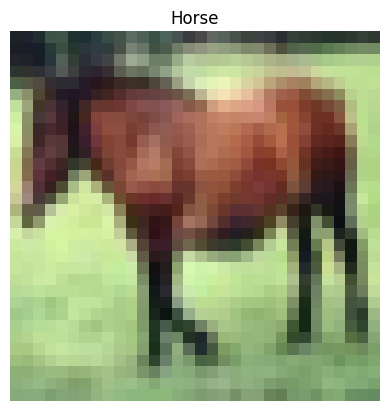

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def show_image(img, title=""):
    """img : (3, 32, 32) float32 in [0,1]  or  uint8 in [0,255]"""
    plt.imshow(img.transpose(1, 2, 0))   # (3,32,32) → (32,32,3)
    plt.title(title)
    plt.axis('off')
    plt.show()

show_image(horse_img, title="Horse")